<a href="https://colab.research.google.com/github/maschu09/mless/blob/main/remote_sensing/Random_forest_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [ ]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [35]:
##matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [5]:
!mkdir -p data
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv
# Note that `cd data`, ..., `cd ..` doesn't work

A subdirectory or file data already exists.
Error occurred while processing: data.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv(r"C:\Users\User\Desktop\MLESS\remote-sensing-lc\data\X_test_sat6.csv", header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data?

&#x1F479;  _Answer:_ image is stored as a flat row of 3,136 values (4 channels × 28 × 28 = 3,136). The channel order is R, G, B, NIR, with 784 values per channel. To extract only green and NIR, select columns 784–1,567 (G) and 2,352–3,135 (NIR).

In [9]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv(r"C:\Users\User\Desktop\MLESS\remote-sensing-lc\data\sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

&#x1F479;  _Answer:_ One-hot encoding avoids implying an ordinal relationship between classes. With integer labels (0, 1, 2, ...), a model might interpret class 3 as "greater than" class 1. One-hot encoding treats all classes as equally distinct. It is also the standard output format for neural network classifiers and supports multi-label classification.

In [11]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv(r"C:\Users\User\Desktop\MLESS\remote-sensing-lc\data\y_test_sat6.csv", header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

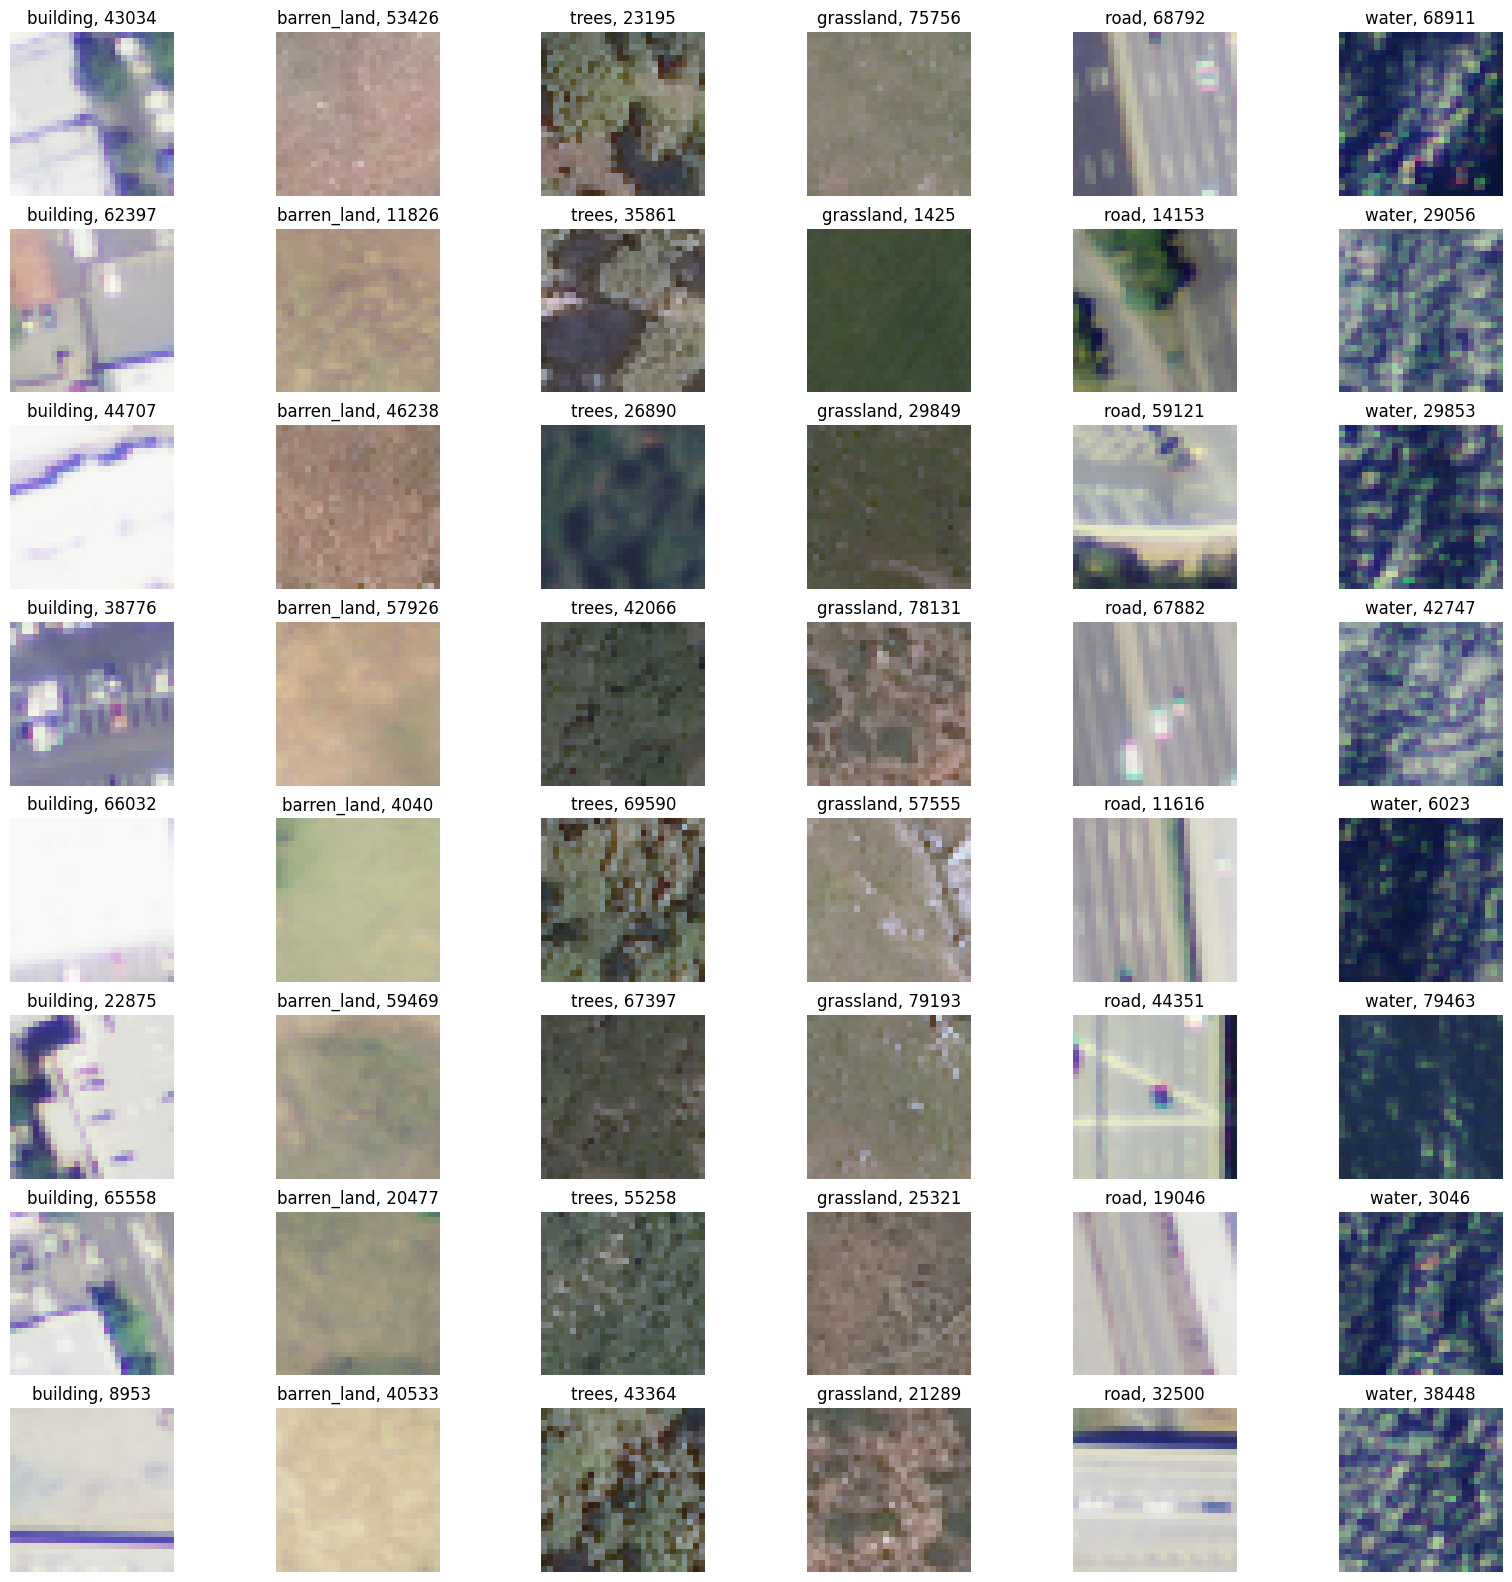

In [13]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [15]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


&#x1F479;  _Question:_ Why use `extend`here and `append` above?

&#x1F479;  _Answer:_ append adds a list as a single nested element (creating a list of lists), which was needed above to keep samples grouped by class. extend adds each element individually into a flat list, which is needed here to create one continuous list of all training/test indices.

&#x1F479;  _Question:_ What is wrong with the above code?

&#x1F479;  _Answer:_ The training and test indices are sampled independently from the same pool, so there may be overlap between training and test sets. This could lead to artificially inflated accuracy, since the model may be tested on samples it has already seen during training.

In [17]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets?

&#x1F479;  _Answer:_ Without shuffling, all samples of class 0 appear first, then class 1, etc. This sequential ordering can introduce bias during training. Shuffling ensures the model sees a random mix of classes, leading to better generalization.

In [19]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
20936,157,154,166,50,158,156,167,52,163,161,...,195,81,173,169,179,67,158,155,165,52
14232,233,234,234,165,232,234,234,164,233,234,...,188,84,194,190,192,92,201,200,198,103
33694,102,105,98,159,111,120,113,172,105,113,...,71,84,98,105,114,140,97,107,104,153
52887,25,39,78,6,31,59,76,7,54,87,...,92,10,62,80,91,11,65,101,95,12
55691,223,205,187,223,223,206,185,224,226,206,...,44,138,142,105,74,145,187,147,131,181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30855,119,120,98,183,122,127,105,193,117,120,...,113,195,126,127,112,191,135,136,123,200
57386,152,141,129,186,153,141,129,187,152,139,...,114,197,131,134,113,197,131,135,115,196
68503,138,132,115,173,138,135,115,182,137,137,...,113,184,137,131,114,180,141,132,120,176
25180,91,107,110,18,66,80,98,13,60,89,...,133,27,135,168,145,47,166,194,164,70


## Define and intialize random classifier from scikit-learn

In [21]:
rf = RandomForestClassifier(n_estimators=100)

## Train the random forest

In [23]:
rf.fit( train_X, train_y)

RandomForestClassifier()

## Check the prediction on the test set

In [25]:
rf.score(test_X, test_y)

0.935

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

=== Per-Class Accuracy ===
  building: 0.970
  barren_land: 0.920
  trees: 0.950
  grassland: 0.890
  road: 0.930
  water: 1.000

Overall accuracy: 0.943

=== Classification Report ===
              precision    recall  f1-score   support

    building       0.82      0.97      0.89       100
 barren_land       0.99      0.92      0.95       100
       trees       0.97      0.95      0.96       100
   grassland       0.94      0.89      0.91       100
        road       0.97      0.93      0.95       100
       water       1.00      1.00      1.00       100

    accuracy                           0.94       600
   macro avg       0.95      0.94      0.94       600
weighted avg       0.95      0.94      0.94       600



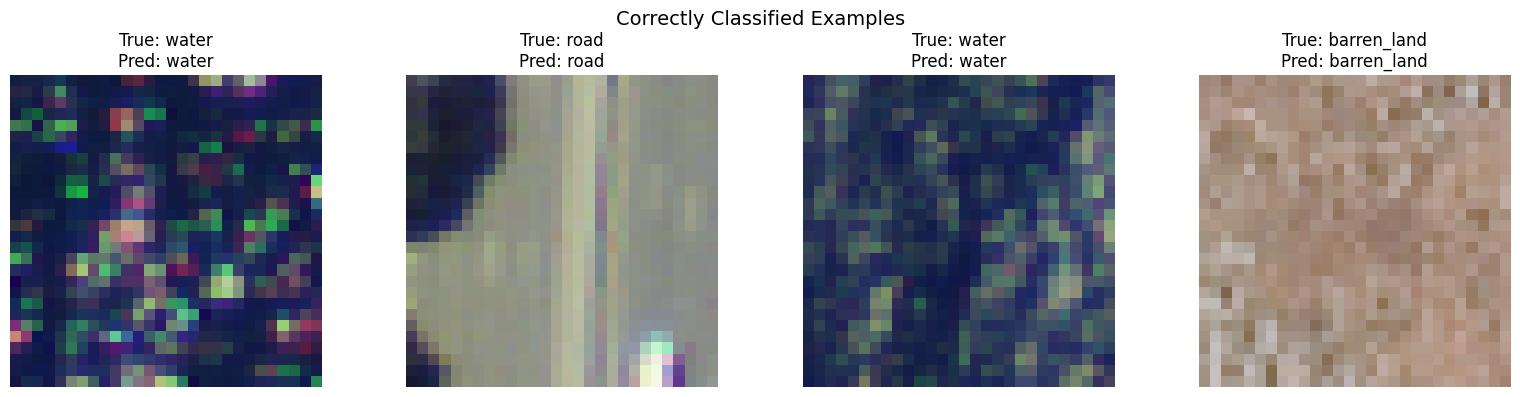

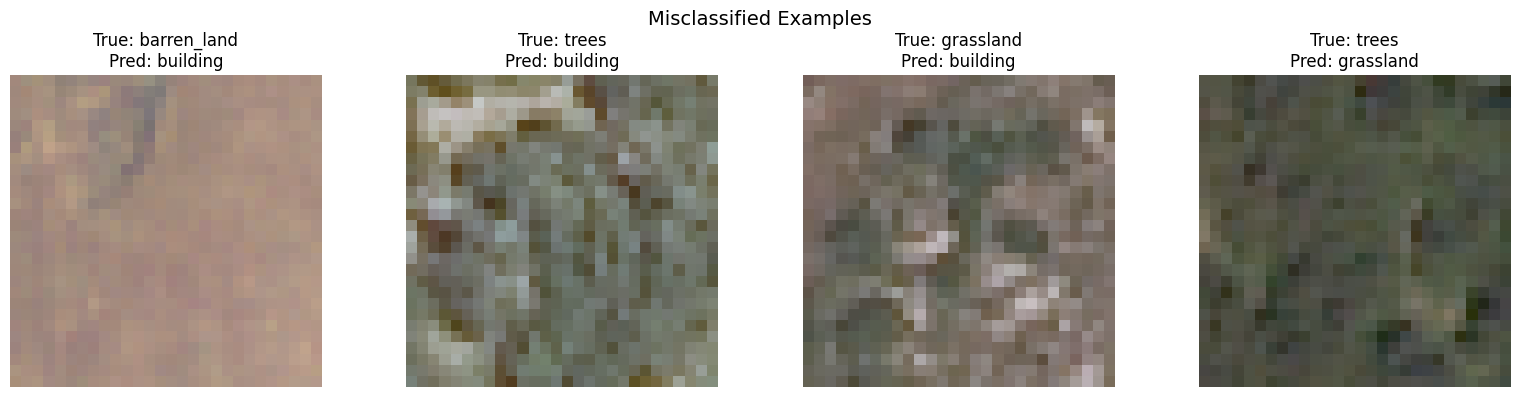

In [27]:
# ============================================================
# Task 2.2: Per-class accuracy + correct/incorrect examples
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
pred_y = rf.predict(test_X)

# Convert one-hot to class indices
true_classes = np.argmax(test_y.values, axis=1)
pred_classes = np.argmax(pred_y, axis=1)

# Per-class accuracy
print("=== Per-Class Accuracy ===")
for i, class_name in enumerate(labels):
    mask = true_classes == i
    class_acc = np.sum(pred_classes[mask] == i) / np.sum(mask)
    print(f"  {class_name}: {class_acc:.3f}")

print(f"\nOverall accuracy: {np.mean(true_classes == pred_classes):.3f}")
print("\n=== Classification Report ===")
print(classification_report(true_classes, pred_classes, target_names=labels))

# --- Plot 4 correct and 4 incorrect examples ---
correct_idx = np.where(true_classes == pred_classes)[0]
incorrect_idx = np.where(true_classes != pred_classes)[0]

# Plot correct examples
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Correctly Classified Examples", fontsize=14)
for i, idx in enumerate(correct_idx[:4]):
    data = np.reshape(test_X.iloc[idx].values, (28, 28, 4))
    axes[i].imshow(data[:, :, :3])
    axes[i].set_title(f"True: {labels[true_classes[idx]]}\nPred: {labels[pred_classes[idx]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Plot incorrect examples
fig, axes = plt.subplots(1, min(4, len(incorrect_idx)), figsize=(16, 4))
fig.suptitle("Misclassified Examples", fontsize=14)
if len(incorrect_idx) == 1:
    axes = [axes]
for i, idx in enumerate(incorrect_idx[:4]):
    axes[i].imshow(np.reshape(test_X.iloc[idx].values, (28, 28, 4))[:, :, :3])
    axes[i].set_title(f"True: {labels[true_classes[idx]]}\nPred: {labels[pred_classes[idx]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# Task 2.3: Random Forest with only R, G, B channels (no NIR)
# ============================================================

# Each image has 4 channels of 28x28=784 pixels: R(0-783), G(784-1567), B(1568-2351), NIR(2352-3135)
# Select only R, G, B columns (first 3 channels = columns 0 to 2351)
rgb_columns = list(range(0, 2352))

train_X_rgb = train_X.iloc[:, rgb_columns]
test_X_rgb = test_X.iloc[:, rgb_columns]

# Train new Random Forest
rf_rgb = RandomForestClassifier(n_estimators=100)
rf_rgb.fit(train_X_rgb, train_y)

# Evaluate
pred_y_rgb = rf_rgb.predict(test_X_rgb)
true_classes_rgb = np.argmax(test_y.values, axis=1)
pred_classes_rgb = np.argmax(pred_y_rgb, axis=1)

print("=== Task 2.3: RGB Only (no NIR) ===")
print(f"Overall accuracy: {np.mean(true_classes_rgb == pred_classes_rgb):.3f}")
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(labels):
    mask = true_classes_rgb == i
    class_acc = np.sum(pred_classes_rgb[mask] == i) / np.sum(mask)
    print(f"  {class_name}: {class_acc:.3f}")

print(f"\nComparison: 4-channel accuracy = 0.943, RGB-only accuracy = {np.mean(true_classes_rgb == pred_classes_rgb):.3f}")

=== Task 2.3: RGB Only (no NIR) ===
Overall accuracy: 0.947

Per-Class Accuracy:
  building: 0.980
  barren_land: 0.930
  trees: 0.960
  grassland: 0.890
  road: 0.920
  water: 1.000

Comparison: 4-channel accuracy = 0.943, RGB-only accuracy = 0.947


In [31]:
# ============================================================
# Task 2.4: Random Forest with R, G, NIR channels (no Blue)
# ============================================================

# R: columns 0-783, G: columns 784-1567, NIR: columns 2352-3135
rg_nir_columns = list(range(0, 1568)) + list(range(2352, 3136))

train_X_rgnir = train_X.iloc[:, rg_nir_columns]
test_X_rgnir = test_X.iloc[:, rg_nir_columns]

# Train new Random Forest
rf_rgnir = RandomForestClassifier(n_estimators=100)
rf_rgnir.fit(train_X_rgnir, train_y)

# Evaluate
pred_y_rgnir = rf_rgnir.predict(test_X_rgnir)
true_classes_rgnir = np.argmax(test_y.values, axis=1)
pred_classes_rgnir = np.argmax(pred_y_rgnir, axis=1)

print("=== Task 2.4: R, G, NIR (no Blue) ===")
print(f"Overall accuracy: {np.mean(true_classes_rgnir == pred_classes_rgnir):.3f}")
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(labels):
    mask = true_classes_rgnir == i
    class_acc = np.sum(pred_classes_rgnir[mask] == i) / np.sum(mask)
    print(f"  {class_name}: {class_acc:.3f}")

print(f"\nComparison: 4-channel = 0.943 | RGB-only = 0.947 | RG+NIR = {np.mean(true_classes_rgnir == pred_classes_rgnir):.3f}")

=== Task 2.4: R, G, NIR (no Blue) ===
Overall accuracy: 0.947

Per-Class Accuracy:
  building: 0.940
  barren_land: 0.950
  trees: 0.950
  grassland: 0.900
  road: 0.950
  water: 0.990

Comparison: 4-channel = 0.943 | RGB-only = 0.947 | RG+NIR = 0.947


In [33]:
# ============================================================
# Task 2.5: Hyperparameter experiment — max_depth
# ============================================================
# Baseline: n_estimators=100, max_depth=None (unlimited)
# Change: set max_depth=10 to limit tree depth
#
# Justification: Unlimited depth can lead to overfitting because each tree
# memorizes the training data. Limiting depth forces the trees to generalize,
# which can make the model more robust but may slightly reduce accuracy.
#
# Expectation: Accuracy might decrease slightly because the trees are less
# expressive, but the model should be more robust (less overfitting).

rf_depth = RandomForestClassifier(n_estimators=100, max_depth=10)
rf_depth.fit(train_X, train_y)

pred_y_depth = rf_depth.predict(test_X)
true_classes_depth = np.argmax(test_y.values, axis=1)
pred_classes_depth = np.argmax(pred_y_depth, axis=1)

print("=== Task 2.5: max_depth=10 (vs default=None) ===")
print(f"Overall accuracy: {np.mean(true_classes_depth == pred_classes_depth):.3f}")
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(labels):
    mask = true_classes_depth == i
    class_acc = np.sum(pred_classes_depth[mask] == i) / np.sum(mask)
    print(f"  {class_name}: {class_acc:.3f}")

print(f"\nComparison: baseline (max_depth=None) = 0.943 | max_depth=10 = {np.mean(true_classes_depth == pred_classes_depth):.3f}")

=== Task 2.5: max_depth=10 (vs default=None) ===
Overall accuracy: 0.938

Per-Class Accuracy:
  building: 0.910
  barren_land: 0.930
  trees: 0.950
  grassland: 0.900
  road: 0.940
  water: 1.000

Comparison: baseline (max_depth=None) = 0.943 | max_depth=10 = 0.938
